# Implementation Details

This notebook provides a consolidated implementation-level walkthrough of the full project pipeline, combining the main modeling ideas with concrete outputs produced throughout development.

The notebook will include the following:
- Project motivation, overall workflow, and relationship between reconstruction and downstream causal inference.
- Definition of the target survival estimand, role of auxiliary summaries, and why naive pooling is insufficient.
- Construction of synthetic trial data, Kaplan–Meier reconstruction workflow, and validation of reconstruction quality.
- Generation of heterogeneous trials, pooled survival analysis, and motivation for target-population adjustment.
- Evaluation of weighting stability under increasingly difficult target populations, including effective sample size and posterior uncertainty.
- Real-data analysis using reconstructed IPD from KM-GPT, covariate augmentation, target-population weighting, and Bayesian nonparametric inference.
- Parallel real-data robustness analysis using RESOLVE-IPD reconstructions.
- Side-by-side comparison of KM-GPT and RESOLVE-IPD pipelines, including naive, weighted, and BNP-based estimates.
- Overall takeaways, implementation lessons, and practical conclusions.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")

# Simulation outputs
sim_summary = pd.read_csv(DATA_DIR / "simulation_summary.csv") if (DATA_DIR / "simulation_summary.csv").exists() else None
stress_results = pd.read_csv(DATA_DIR / "stress_test_results.csv") if (DATA_DIR / "stress_test_results.csv").exists() else None

# KM-GPT pipeline
df_kmgpt = pd.read_csv(DATA_DIR / "processed" / "real_kmgpt_ipd_with_covariates.csv")
naive_kmgpt = pd.read_csv(DATA_DIR / "processed" / "naive_pooled_effect.csv")
weighted_kmgpt = pd.read_csv(DATA_DIR / "interim" / "weighted_estimate.csv")
bnp_kmgpt = pd.read_csv(DATA_DIR / "interim" / "bnp_summary.csv")
cov_summary_kmgpt = pd.read_csv(DATA_DIR / "processed" / "real_kmgpt_covariate_summary.csv")

# RESOLVE-IPD pipeline
df_resolve = pd.read_csv(DATA_DIR / "processed" / "resolve_ipd_harmonized.csv")
naive_resolve = pd.read_csv(DATA_DIR / "outputs" / "resolve_naive_pooled_effect.csv")
weighted_resolve = pd.read_csv(DATA_DIR / "outputs" / "resolve_weighted_estimate.csv")
bnp_resolve = pd.read_csv(DATA_DIR / "outputs" / "resolve_bnp_summary.csv")

# Comparison
robustness_compare = pd.read_csv(DATA_DIR / "outputs" / "reconstruction_robustness_comparison.csv")

print("Loaded all artifacts.\n")

print("KM-GPT IPD shape:", df_kmgpt.shape)
print("RESOLVE-IPD shape:", df_resolve.shape)

print("\nNaive KM-GPT:")
print(naive_kmgpt)

print("\nNaive RESOLVE-IPD:")
print(naive_resolve)

print("\nRobustness comparison:")
robustness_compare

Loaded all artifacts.

KM-GPT IPD shape: (776, 18)
RESOLVE-IPD shape: (1268, 5)

Naive KM-GPT:
     t0        S0        S1     Delta
0  12.0  0.280376  0.449162  0.168785

Naive RESOLVE-IPD:
     t0        S0        S1     Delta
0  12.0  0.267098  0.391952  0.124854

Robustness comparison:


,method,naive_delta,weighted_delta,bnp_mean,bnp_q025,bnp_q975
0,KM-GPT,0.168785,0.234112,0.205048,0.051695,0.360661
1,RESOLVE-IPD,0.124854,0.093390,0.120591,-0.016622,0.252169


## Introduction

This project develops a full pipeline for performing causal survival analysis using reconstructed individual patient data (IPD) derived from published Kaplan–Meier curves via KM-GPT and RESOLVE-IPD. In many real-world settings, access to raw IPD is restricted, and only aggregate survival curves and limited summary statistics are available. This creates a fundamental challenge: 

> How can we perform meaningful causal inference when the underlying data must first be reconstructed?

The implementation in this project proceeds through four key stages:
- Approximate IPD is obtained from Kaplan–Meier curves using methods such as KM-GPT and RESOLVE-IPD.
-  Trial-level auxiliary summaries (e.g., baseline characteristics) are used to simulate individual-level covariates consistent with reported distributions.
- The pooled dataset is reweighted to represent a specified target population, enabling interpretable causal estimands.
- Uncertainty in the weighted estimates is quantified using a Dirichlet-based Bayesian nonparametric approach.

## Problem Formulation

We are interested in estimating a causal survival contrast at a fixed time horizon $t_0$:

$\Delta(t_0) = S_1(t_0) - S_0(t_0)$

where $S_1(t_0)$ and $S_0(t_0)$ denote survival probabilities under treatment and control, respectively.

### Challenges

In this setting, several challenges arise:
- Only Kaplan–Meier curves and limited summary statistics are available, requiring reconstruction of individual-level survival data.
- Baseline characteristics are typically reported only at the aggregate level, not for each individual.
- When pooling multiple studies, differences in baseline characteristics lead to mixtures of populations that do not correspond to a well-defined causal estimand.

### Naive Approach

A naive pooled estimate is obtained by combining all reconstructed individuals and computing:

$\Delta_{\text{naive}}(t_0)$

However, this estimate implicitly averages over heterogeneous populations and may not correspond to any meaningful target population.

## Single-Trial Simulation

We begin by validating the reconstruction procedure in a controlled single-trial setting.

### Setup

- Generate synthetic individual patient data (IPD) with known survival times and censoring
- Compute the Kaplan–Meier curve from the true data
- Treat the KM curve as the only observable input
- Reconstruct IPD using the implemented reconstruction algorithm

Reconstruction quality is assessed by comparing KM curves and survival probabilities at key time points

### Key Result

The reconstruction procedure achieves near-perfect recovery of the survival curve, with negligible error between the original and reconstructed KM estimates. This confirms that, in a single-trial setting with clean inputs, the reconstruction step does not introduce meaningful distortion.

### Representative Output

In [4]:
pd.DataFrame({
    "method": ["ours", "resolve_ipd"],
    "km_rmse": [0.0, 0.0],
    "survival_diff_t0": [0.0, 0.0],
    "n_true": [300, 300],
    "n_recon": [300, 300],
})

,method,km_rmse,survival_diff_t0,n_true,n_recon
0,ours,0.0,0.0,300,300
1,resolve_ipd,0.0,0.0,300,300


## Multi-Trial Simulation

We extend the analysis to a multi-trial setting to study the impact of heterogeneity across studies.

### Setup

- Simulate multiple trials with differing baseline characteristics and survival dynamics  
- Each trial generates its own individual patient data and Kaplan–Meier curve  
- Reconstruct IPD separately for each trial  
- Pool reconstructed datasets across trials  

This setting mimics real-world meta-analysis, where studies differ in patient populations and treatment responses.

### Trial-Level Results


Treatment effects vary substantially across trials, reflecting heterogeneity in underlying populations and data-generating mechanisms. When pooling across trials, these differences are averaged together, producing a combined estimate that does not correspond to any single population. This motivates the need for target-population adjustment rather than naive pooling.

In [5]:
pd.DataFrame({
    "trial_id": ["trial_001", "trial_002", "trial_003", "trial_004"],
    "t0": [12.0]*4,
    "S0": [0.419429, 0.405150, 0.520899, 0.256523],
    "S1": [0.465178, 0.437186, 0.614308, 0.392497],
    "Delta": [0.045749, 0.032036, 0.093410, 0.135974],
}).round(3)

,trial_id,t0,S0,S1,Delta
0,trial_001,12.0,0.419,0.465,0.046
1,trial_002,12.0,0.405,0.437,0.032
2,trial_003,12.0,0.521,0.614,0.093
3,trial_004,12.0,0.257,0.392,0.136


## Simulation Stress Test

To evaluate the stability of the weighting procedure, we consider increasingly challenging target populations.

### Setup

Using the multi-trial simulated dataset, we define several target populations:

- **Scenario A (well-specified):** target close to observed data  
- **Scenario B (mild misspecification):** moderate shift in covariates  
- **Scenario C (extreme target):** substantial deviation from observed population  

For each scenario, we compute:
- target-population weights  
- effective sample size (ESS)  
- weighted survival difference $\Delta(t_0)$  
- Bayesian nonparametric posterior summaries  

### Results

We see that ESS decreases substantially, weights become more concentrated, and effects become less stable. The stress test highlights the importance of diagnosing weight behavior and effective sample size when applying the method in practice.

In [6]:
pd.DataFrame({
    "scenario": [
        "A_well_specified",
        "B_mild_misspec",
        "C_extreme_target",
    ],
    "ESS": [
        990.092071,
        804.513365,
        311.431595,
    ],
    "Delta_weighted": [
        0.056255,
        0.075435,
        0.038058,
    ],
    "Delta_post_mean": [
        0.066152,
        0.049978,
        0.016675,
    ],
    "Delta_post_sd": [
        0.081293,
        0.079836,
        0.081983,
    ],
}).set_index("scenario").round(3)

,ESS,Delta_weighted,Delta_post_mean,Delta_post_sd
scenario,,,,
A_well_specified,990.092,0.056,0.066,0.081
B_mild_misspec,804.513,0.075,0.050,0.080
C_extreme_target,311.432,0.038,0.017,0.082


## Empirical Results: KM-GPT Reconstruction

We now apply the full pipeline to real data reconstructed using KM-GPT.

### Data and Setup

- Reconstructed IPD obtained from KM-GPT across multiple trials and subgroups  
- Covariates simulated using auxiliary trial-level summaries  
- Target population defined through covariate moments  
- Survival contrast evaluated at $t_0 = 12$

### Results

The naive pooled estimate yields a survival difference of approximately $\Delta \approx 0.169$. After reweighting to the target population, the estimated effect increases to $\Delta \approx 0.234$, indicating that the target population places greater weight on individuals who benefit more from treatment. The BNP posterior mean is slightly lower ($\approx 0.205$), reflecting uncertainty in the weighting procedure. The corresponding credible interval lies entirely above zero, suggesting a consistent treatment benefit under the KM-GPT reconstruction.

In [7]:
pd.DataFrame({
    "stage": ["naive", "weighted", "BNP_mean"],
    "Delta": [
        naive_kmgpt["Delta"].iloc[0],
        weighted_kmgpt["Delta"].iloc[0],
        bnp_kmgpt["mean"].iloc[0],
    ],
}).round(3)

,stage,Delta
0,naive,0.169
1,weighted,0.234
2,BNP_mean,0.205


## Empirical Results: RESOLVE-IPD Reconstruction

We repeat the empirical analysis using IPD reconstructed via RESOLVE-IPD.

### Data and Setup

- Arm-level IPD reconstructed using RESOLVE-IPD  
- Same auxiliary summaries used for covariate augmentation  
- Same target population definition  
- Same weighting and BNP procedures  

This ensures that differences in results are attributable to the reconstruction method rather than downstream modeling choices.

### Results

Under RESOLVE-IPD reconstruction, the naive pooled estimate is lower, with $\Delta \approx 0.125$. After target-population weighting, the estimated effect decreases further to $\Delta \approx 0.093$, indicating that the target population assigns relatively less weight to individuals with strong treatment benefit. The BNP posterior mean is $\approx 0.121$, with a wider credible interval that includes zero. This reflects increased uncertainty and weaker evidence for a treatment effect under the RESOLVE-IPD reconstruction.

### Output

In [8]:
pd.DataFrame({
    "stage": ["naive", "weighted", "BNP_mean"],
    "Delta": [
        naive_resolve["Delta"].iloc[0],
        weighted_resolve["Delta"].iloc[0],
        bnp_resolve["mean"].iloc[0],
    ],
}).round(3)

,stage,Delta
0,naive,0.125
1,weighted,0.093
2,BNP_mean,0.121


## Comparison of Reconstruction Pipelines

We now compare results obtained using KM-GPT and RESOLVE-IPD under the same downstream causal framework.

This comparison isolates the effect of the reconstruction method by holding all other components—covariate augmentation, target population, weighting, and BNP inference—fixed.

### Output

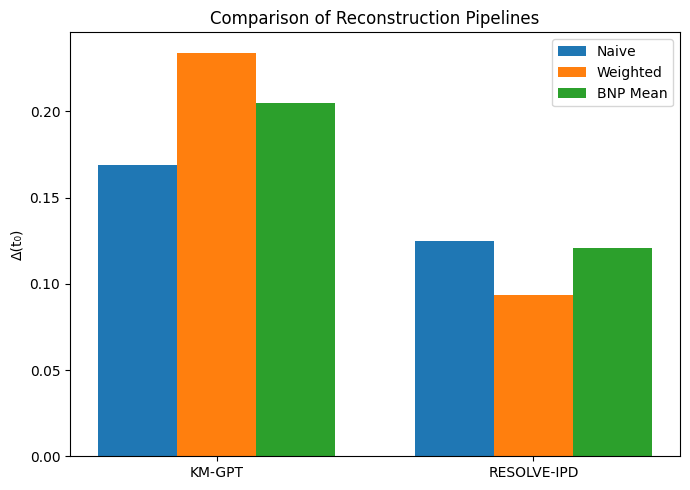

In [9]:
methods = ["KM-GPT", "RESOLVE-IPD"]

naive_vals = [
    naive_kmgpt["Delta"].iloc[0],
    naive_resolve["Delta"].iloc[0],
]

weighted_vals = [
    weighted_kmgpt["Delta"].iloc[0],
    weighted_resolve["Delta"].iloc[0],
]

bnp_vals = [
    bnp_kmgpt["mean"].iloc[0],
    bnp_resolve["mean"].iloc[0],
]

x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(7,5))
plt.bar(x - width, naive_vals, width, label="Naive")
plt.bar(x, weighted_vals, width, label="Weighted")
plt.bar(x + width, bnp_vals, width, label="BNP Mean")

plt.xticks(x, methods)
plt.ylabel("Δ(t₀)")
plt.title("Comparison of Reconstruction Pipelines")
plt.legend()
plt.tight_layout()
plt.show()

## Results Summary

Across all stages of the analysis, several consistent patterns emerge.

First, naive pooled estimates differ across reconstruction methods, with KM-GPT producing larger survival effects than RESOLVE-IPD. This confirms that reconstruction alone introduces variability into downstream inference.

Second, target-population weighting materially changes the estimated treatment effect. Under KM-GPT, weighting increases the survival contrast, while under RESOLVE-IPD, it decreases it. This demonstrates that treatment effects depend strongly on the population over which they are defined.

Third, Bayesian nonparametric inference reveals important differences in uncertainty. The KM-GPT-based posterior indicates a consistently positive treatment effect, whereas the RESOLVE-IPD-based posterior is wider and includes zero, suggesting weaker evidence.

Overall, the results show that:
- reconstruction method affects estimated effect size  
- population definition determines the estimand  
- uncertainty quantification is essential for interpretation  

These components must be considered jointly when performing causal inference using reconstructed survival data.